In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Código para calcular correlación entre estaciones para una variable dada (por defecto O3).
Lee archivos CSV de una carpeta (por ejemplo, los originales o los imputados),
alinea las series por fecha y calcula la matriz de correlación.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================================
# CONFIGURACIÓN (modifica según tu caso)
# ============================================================================

# Carpeta donde están los CSV de cada estación (puede ser la original o imputed_global)
DATA_DIR = os.path.expanduser("/Volumes/copia seguridad1/enviar_benja/imputed_global/")

# Variable a correlacionar (columna)
VAR = 'O3'

# Método de correlación: 'pearson', 'spearman', 'kendall'
CORR_METHOD = 'pearson'

# Umbral mínimo de datos comunes (fracción) para considerar un par de estaciones
MIN_COMMON_FRAC = 0.3   # al menos 30% de horas en común

# Guardar gráficos y tablas
OUTPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/correlaciones_estaciones")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================================
# FUNCIONES AUXILIARES
# ============================================================================

def clean_series(serie):
    """
    Asegura que la serie tenga índice único y ordenado.
    - Elimina duplicados de índice (conserva el primero)
    - Ordena por índice
    - Convierte a numérico (coerce)
    """
    # Forzar tipo numérico
    serie = pd.to_numeric(serie, errors='coerce')
    # Eliminar duplicados de índice (keep='first' mantiene el primero)
    if not serie.index.is_unique:
        serie = serie[~serie.index.duplicated(keep='first')]
    # Ordenar índice
    serie = serie.sort_index()
    return serie

def load_station_data(filepath, var):
    """Carga un CSV, asume índice datetime, devuelve Serie limpia con la variable."""
    df = pd.read_csv(filepath, index_col=0, parse_dates=True)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    if var not in df.columns:
        raise ValueError(f"Variable '{var}' no encontrada en {filepath}")
    serie = df[var].copy()
    serie = clean_series(serie)
    return serie

def get_series_from_folder(folder_path, var):
    """
    Recorre todos los archivos CSV en folder_path y devuelve un dict {nombre: Serie}.
    Si el archivo contiene varias estaciones (columna 'Estacion'), extrae cada una.
    Cada serie es limpiada (índice único y ordenado).
    """
    series_dict = {}
    files = list(Path(folder_path).glob("*.csv"))
    for f in files:
        name = f.stem
        df = pd.read_csv(f, index_col=0, parse_dates=True)
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        # Verificar si tiene columna 'Estacion' (caso por transecto)
        if 'Estacion' in df.columns:
            # Agrupar por estación
            for estacion, group in df.groupby('Estacion'):
                if var in group.columns:
                    serie = group[var].copy()
                    serie = clean_series(serie)
                    series_dict[f"{name}_{estacion}"] = serie
        else:
            # Archivo de una sola estación
            if var in df.columns:
                serie = df[var].copy()
                serie = clean_series(serie)
                series_dict[name] = serie
    return series_dict

def align_series(series_dict):
    """Alinea todas las series por índice de tiempo (unión externa) y devuelve DataFrame."""
    # Asegurar que todas las series tienen índice ordenado y único (ya lo hicimos en get_series)
    # Concatenar
    df_all = pd.concat(series_dict, axis=1)
    # Renombrar columnas si son MultiIndex (por si acaso)
    df_all.columns = [col if isinstance(col, str) else col[1] for col in df_all.columns]
    return df_all

def compute_correlation_matrix(df, method='pearson', min_common_frac=0.5):
    """
    Calcula matriz de correlación entre columnas, ignorando pares con pocos datos comunes.
    """
    n = len(df)
    min_common = int(n * min_common_frac)
    corr_matrix = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)
    for i, col1 in enumerate(df.columns):
        for j, col2 in enumerate(df.columns):
            if i == j:
                corr_matrix.loc[col1, col2] = 1.0
                continue
            # Datos no nulos en ambos
            mask = df[col1].notna() & df[col2].notna()
            if mask.sum() < min_common:
                corr_matrix.loc[col1, col2] = np.nan
            else:
                corr_matrix.loc[col1, col2] = df[col1][mask].corr(df[col2][mask], method=method)
    return corr_matrix

def plot_correlation_heatmap(corr_matrix, title, save_path):
    """Dibuja mapa de calor de la matriz de correlación."""
    plt.figure(figsize=(12, 10))
    mask = corr_matrix.isna()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5, mask=mask,
                cbar_kws={'shrink': 0.8})
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Gráfico guardado: {save_path}")

def plot_correlation_clustermap(corr_matrix, title, save_path):
    """Mapa de calor con clustering jerárquico."""
    if corr_matrix.isna().all().all():
        print("  Matriz vacía, no se puede generar clustermap.")
        return
    # Reemplazar NaN por 0 para que no rompa el clustering (pero puede distorsionar)
    corr_filled = corr_matrix.fillna(0)
    g = sns.clustermap(corr_filled, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                       figsize=(12, 10), linewidths=0.5,
                       cbar_kws={'shrink': 0.8})
    g.ax_heatmap.set_title(title)
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Clustermap guardado: {save_path}")

# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    print("="*60)
    print(f"Cálculo de correlación ({CORR_METHOD}) para variable '{VAR}'")
    print("="*60)

    # 1. Cargar series
    print(f"\nCargando datos desde: {DATA_DIR}")
    series = get_series_from_folder(DATA_DIR, VAR)
    if not series:
        print("No se encontraron series válidas. Revise la carpeta.")
        exit()
    print(f"Estaciones encontradas: {list(series.keys())}")

    # 2. Alinear temporalmente
    df_aligned = align_series(series)
    print(f"Periodo: {df_aligned.index.min()} a {df_aligned.index.max()}")
    print(f"Total de horas: {len(df_aligned)}")

    # 3. Calcular matriz de correlación
    corr_matrix = compute_correlation_matrix(df_aligned, method=CORR_METHOD,
                                              min_common_frac=MIN_COMMON_FRAC)
    # Guardar matriz en CSV
    corr_csv = os.path.join(OUTPUT_DIR, f"correlacion_{VAR}_{CORR_METHOD}.csv")
    corr_matrix.to_csv(corr_csv)
    print(f"\nMatriz de correlación guardada en: {corr_csv}")

    # 4. Generar gráficos
    title = f"Correlación {CORR_METHOD} de {VAR} entre estaciones"
    plot_correlation_heatmap(corr_matrix, title,
                             os.path.join(OUTPUT_DIR, f"heatmap_{VAR}_{CORR_METHOD}.png"))
    plot_correlation_clustermap(corr_matrix, title,
                                os.path.join(OUTPUT_DIR, f"clustermap_{VAR}_{CORR_METHOD}.png"))

    # 5. Mostrar las 10 correlaciones más altas (fuera de la diagonal)
    # Obtener matriz triangular superior sin diagonal
    corr_triu = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    corr_triu = corr_triu.unstack().dropna().sort_values(ascending=False)
    if not corr_triu.empty:
        print("\nTop 10 pares con mayor correlación:")
        for (col1, col2), val in corr_triu.head(10).items():
            print(f"  {col1} vs {col2}: {val:.3f}")
    else:
        print("\nNo hay pares con suficientes datos comunes.")

    print("\nProceso completado. Revise la carpeta:")
    print(f"  {OUTPUT_DIR}")

Cálculo de correlación (pearson) para variable 'O3'

Cargando datos desde: /Volumes/copia seguridad1/enviar_benja/imputed_global/
Estaciones encontradas: ['T1_E1_Alicante_Estacion 1', 'T1_E2_Elda_Estacion 2', 'T1_E2_Elda_T1_E2_Elda', 'T2_E1_Elche_Estacion 1', 'T2_E1_Elche_T2_E1_Elche', 'T2_E2_Elda_Estacion 2', 'T2_E2_Elda_T2_E2_Elda', 'T3_E1_Valencia_Estacion 1', 'T3_E2_Buñol_Estacion 2', 'T4_E1_Valencia_Estacion 1', 'T4_E2_Villar_Arzobispo_Estacion 2', 'T6_E1_Castellon_Estacion 1', 'T6_E1_Castellon_T6_E1_Castellon', 'T6_E2_Onda_Estacion 2', 'T7_E1_Sant_Jordi_Estacion 1', 'T7_E2_Coratxa_Estacion 2', 'T7_E3_Zorita_Estacion 3', 'T8_E1_Sant_Jordi_Estacion 1', 'T8_E2_Morella_Estacion 2', 'T8_E3_Zorita_Estacion 3']
Periodo: 2006-01-01 00:00:00 a 2068-01-01 00:00:00
Total de horas: 320214

Matriz de correlación guardada en: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/correlaciones_estaciones/correlacion_O3_pearson.csv
  Gráfico guardado: /Users/benjamincarbonell/Documents/GitHub/TFGF

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product

# ============================================================================
# CONFIGURACIÓN (modificar según tu caso)
# ============================================================================
DATA_DIR = "/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/"
VAR_LIST = ['NO', 'NO2', 'O3']
LAG_MIN = -24
LAG_MAX = 24
STEP = 1
CORR_METHOD = 'pearson'
USE_TRANSECT = False
TRANSECT_FILE = ""
LIMIT_STATIONS = None
MIN_COMMON_FRAC = 0.2

# Función para extraer la ciudad (o identificador de ubicación) del nombre de estación
def extract_location(station_name):
    # Ejemplo: "T1_E1_Alicante" -> "Alicante"
    # Si el nombre tiene guiones bajos, toma la última parte
    parts = station_name.split('_')
    return parts[-1] if len(parts) > 1 else station_name

# ============================================================================
# FUNCIONES
# ============================================================================
def load_all_series(data_dir, var_list, use_transect=False, transect_path=None, limit_stations=None):
    series_dict = {}  # clave: (nombre_estacion, variable) -> (serie, ubicacion)
    if use_transect:
        df = pd.read_csv(transect_path, index_col=0, parse_dates=True, low_memory=False)
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        estaciones = df['Estacion'].unique()
        if limit_stations:
            estaciones = [e for e in estaciones if e in limit_stations]
        for est in estaciones:
            df_est = df[df['Estacion'] == est]
            for var in var_list:
                if var in df_est.columns:
                    serie = pd.to_numeric(df_est[var], errors='coerce')
                    serie = serie.groupby(serie.index).first()
                    series_dict[(est, var)] = (serie, extract_location(est))
    else:
        files = list(Path(data_dir).glob("*.csv"))
        for f in files:
            est_name = f.stem
            if limit_stations and est_name not in limit_stations:
                continue
            df = pd.read_csv(f, index_col=0, parse_dates=True, low_memory=False)
            if not isinstance(df.index, pd.DatetimeIndex):
                df.index = pd.to_datetime(df.index)
            for var in var_list:
                if var in df.columns:
                    serie = pd.to_numeric(df[var], errors='coerce')
                    series_dict[(est_name, var)] = (serie, extract_location(est_name))
    return series_dict

def cross_correlation(serie1, serie2, lags, method='pearson', min_common=100):
    combined = pd.concat([serie1, serie2], axis=1).dropna()
    if len(combined) < min_common:
        return {lag: np.nan for lag in lags}
    s1 = combined.iloc[:, 0]
    s2 = combined.iloc[:, 1]
    results = {}
    for lag in lags:
        if lag >= 0:
            corr = s1.corr(s2.shift(-lag), method=method)
        else:
            corr = s1.shift(lag).corr(s2, method=method)
        results[lag] = corr
    return results

def compute_all_correlations(series_dict, lags, method='pearson', min_common_frac=0.3):
    stations_vars = list(series_dict.keys())
    total_pairs = len(stations_vars) * len(stations_vars) * len(lags)
    print(f"Calculando {total_pairs} combinaciones...")
    min_common = int(min(len(series_dict[k][0]) for k in series_dict) * min_common_frac)
    min_common = max(min_common, 10)
    results = []
    for (est1, var1), (est2, var2) in product(stations_vars, repeat=2):
        # Excluir si es la misma estación (mismo nombre completo)
        if est1 == est2:
            continue
        # Excluir si representan la misma ubicación (ciudad)
        loc1 = series_dict[(est1, var1)][1]
        loc2 = series_dict[(est2, var2)][1]
        if loc1 == loc2:
            continue
        serie1 = series_dict[(est1, var1)][0]
        serie2 = series_dict[(est2, var2)][0]
        corr_dict = cross_correlation(serie1, serie2, lags, method=method, min_common=min_common)
        for lag, corr in corr_dict.items():
            if not np.isnan(corr):
                results.append((est1, var1, est2, var2, lag, corr))
    return results

# ============================================================================
# EJECUCIÓN
# ============================================================================
if __name__ == "__main__":
    print("="*60)
    print("Cálculo de correlaciones cruzadas (excluyendo misma estación y misma ubicación)")
    print("="*60)

    series = load_all_series(DATA_DIR, VAR_LIST, USE_TRANSECT, TRANSECT_FILE, LIMIT_STATIONS)
    if not series:
        print("No se encontraron series.")
        exit()
    print(f"Series cargadas: {len(series)}")

    lags = list(range(LAG_MIN, LAG_MAX+1, STEP))
    print(f"Rango de lags: {LAG_MIN} a {LAG_MAX} (paso {STEP}) -> {len(lags)} lags")

    results = compute_all_correlations(series, lags, method=CORR_METHOD, min_common_frac=MIN_COMMON_FRAC)
    print(f"Combinaciones válidas: {len(results)}")

    if len(results) == 0:
        print("No hay resultados. Ajusta MIN_COMMON_FRAC o revisa los datos.")
        exit()

    df = pd.DataFrame(results, columns=['est_origen', 'var_origen', 'est_destino', 'var_destino', 'lag', 'correlacion'])

    top100_max = df.nlargest(100, 'correlacion')
    top100_min = df.nsmallest(100, 'correlacion')

    print("\n" + "="*60)
    print("TOP 100 CORRELACIONES MÁS ALTAS")
    print("="*60)
    print(top100_max.to_string(index=False))

    print("\n" + "="*60)
    print("TOP 100 CORRELACIONES MÁS BAJAS (más negativas)")
    print("="*60)
    print(top100_min.to_string(index=False))

    output_csv = "cross_correlations_all.csv"
    df.to_csv(output_csv, index=False)
    print(f"\nResultados completos guardados en {output_csv}")

    # Gráfico opcional
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(range(100), top100_max['correlacion'].values)
    axes[0].set_yticks(range(100))
    axes[0].set_yticklabels([f"{row['est_origen']} {row['var_origen']} → {row['est_destino']} {row['var_destino']} (lag {row['lag']})" 
                             for _, row in top100_max.iterrows()], fontsize=8)
    axes[0].set_title("Top 100 correlaciones más altas")
    axes[0].invert_yaxis()
    axes[1].barh(range(100), top100_min['correlacion'].values, color='salmon')
    axes[1].set_yticks(range(100))
    axes[1].set_yticklabels([f"{row['est_origen']} {row['var_origen']} → {row['est_destino']} {row['var_destino']} (lag {row['lag']})" 
                             for _, row in top100_min.iterrows()], fontsize=8)
    axes[1].set_title("Top 100 correlaciones más bajas")
    axes[1].invert_yaxis()
    plt.tight_layout()
    plt.savefig("top_correlations.png", dpi=150)
    plt.show()
    print("Gráfico guardado como top_correlations.png")

Cálculo de correlaciones cruzadas (excluyendo misma estación y misma ubicación)
Series cargadas: 48
Rango de lags: -24 a 24 (paso 1) -> 49 lags
Calculando 112896 combinaciones...
Combinaciones válidas: 0
No hay resultados. Ajusta MIN_COMMON_FRAC o revisa los datos.


TypeError: Column 'correlacion' has dtype object, cannot use method 'nlargest' with this dtype

: 

# Correlacion entre 2 estaciones

Correlación cruzada entre T6_E1_Sant_Jordi_outliers.csv (NO2) y
T6_E2_Coratxa_outliers.csv (O3)
Rango de lags: 0 a 24 horas
Serie 1: 127138 horas, 0 NaN
Serie 2: 113645 horas, 0 NaN
Lags a evaluar: 0 ... 24 (total 25)

Máxima correlación |0.062| en lag = 6 horas
Interpretación: O3 en T6_E2_Coratxa_outliers.csv se retrasa 6 horas respecto a NO2 en T6_E1_Sant_Jordi_outliers.csv


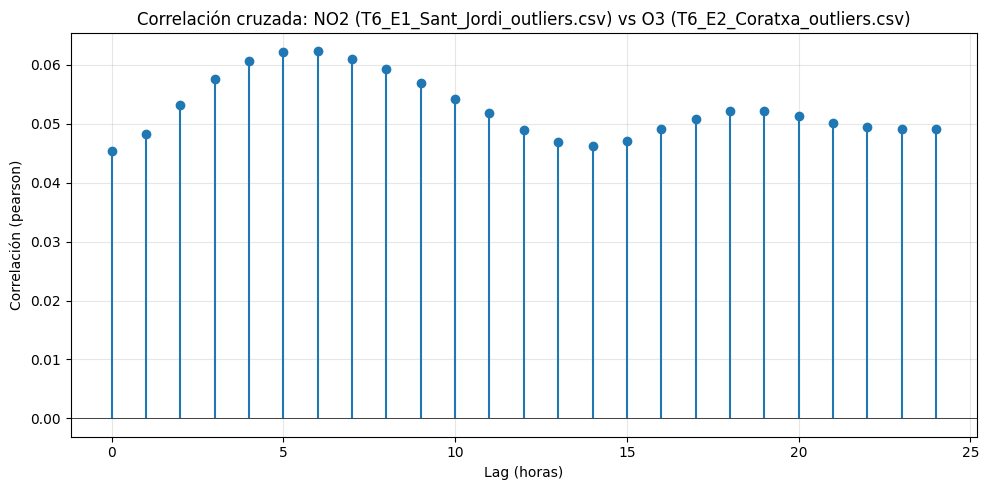


Resultados guardados en cross_corr_T6_E1_Sant_Jordi_outliers.csv_NO2_vs_T6_E2_Coratxa_outliers.csv_O3.csv


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# CONFIGURACIÓN (¡CÁMBIALO A TUS RUTAS Y VARIABLES!)
# ============================================================================
# Rutas de los archivos CSV de las dos estaciones (ajusta a tus archivos)
ruta_estacion1 = "/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T6_E1_Sant_Jordi_outliers.csv"
ruta_estacion2 = "/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T6_E2_Coratxa_outliers.csv"

# Variables a correlacionar (ej. 'O3', 'NO2', 'NO')
var1 = 'NO2'
var2 = 'O3'

# Rango de lags (horas). Por defecto ±24
lag_min = 0
lag_max = 24
step = 1

# Método de correlación: 'pearson', 'spearman', 'kendall'
corr_method = 'pearson'

# Umbral mínimo de datos comunes (fracción) para cada lag
min_common_frac = 0.5

# Si la fecha no es índice, especifica el nombre de la columna (ej. 'datetime')
fecha_col = None  # None asume que la primera columna es el índice datetime

# ============================================================================
# FUNCIONES
# ============================================================================
def load_series(filepath, var, fecha_col=None):
    """
    Carga la serie temporal de un archivo CSV.
    Si fecha_col es None, se asume que la primera columna es el índice datetime.
    """
    if fecha_col is None:
        df = pd.read_csv(filepath, index_col=0, parse_dates=True)
    else:
        df = pd.read_csv(filepath, parse_dates=[fecha_col])
        df.set_index(fecha_col, inplace=True)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    if var not in df.columns:
        raise ValueError(f"Variable '{var}' no encontrada en {filepath}. Columnas: {df.columns.tolist()}")
    serie = pd.to_numeric(df[var], errors='coerce')
    return serie

def cross_correlation(serie1, serie2, lags, method='pearson', min_common=10):
    """
    Calcula la correlación cruzada entre dos series para una lista de lags.
    Retorna un diccionario {lag: corr}.
    """
    results = {}
    for lag in lags:
        if lag >= 0:
            # serie1 en t vs serie2 en t+lag
            s1 = serie1
            s2 = serie2.shift(-lag)
        else:
            # serie1 en t+lag vs serie2 en t (equivalente a lag negativo)
            s1 = serie1.shift(lag)
            s2 = serie2
        # Alinear y eliminar NaN
        combined = pd.concat([s1, s2], axis=1).dropna()
        if len(combined) < min_common:
            results[lag] = np.nan
        else:
            results[lag] = combined.iloc[:,0].corr(combined.iloc[:,1], method=method)
    return results

# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================
if __name__ == "__main__":
    print("="*60)
    print(f"Correlación cruzada entre {os.path.basename(ruta_estacion1)} ({var1}) y")
    print(f"{os.path.basename(ruta_estacion2)} ({var2})")
    print(f"Rango de lags: {lag_min} a {lag_max} horas")
    print("="*60)

    # Cargar series
    try:
        s1 = load_series(ruta_estacion1, var1, fecha_col)
        s2 = load_series(ruta_estacion2, var2, fecha_col)
    except Exception as e:
        print(f"Error al cargar los datos: {e}")
        exit()

    print(f"Serie 1: {len(s1)} horas, {s1.isna().sum()} NaN")
    print(f"Serie 2: {len(s2)} horas, {s2.isna().sum()} NaN")

    # Definir lags
    lags = list(range(lag_min, lag_max+1, step))
    print(f"Lags a evaluar: {lags[0]} ... {lags[-1]} (total {len(lags)})")

    # Calcular correlación
    min_common = int(min(len(s1), len(s2)) * min_common_frac)
    min_common = max(min_common, 10)
    corr_results = cross_correlation(s1, s2, lags, method=corr_method, min_common=min_common)

    # Mostrar el lag de máxima correlación absoluta
    valid_results = {lag: corr for lag, corr in corr_results.items() if not np.isnan(corr)}
    if valid_results:
        max_lag = max(valid_results, key=lambda l: abs(valid_results[l]))
        max_corr = valid_results[max_lag]
        print(f"\nMáxima correlación |{max_corr:.3f}| en lag = {max_lag} horas")
        if max_lag > 0:
            print(f"Interpretación: {var2} en {os.path.basename(ruta_estacion2)} se retrasa {max_lag} horas respecto a {var1} en {os.path.basename(ruta_estacion1)}")
        elif max_lag < 0:
            print(f"Interpretación: {var1} en {os.path.basename(ruta_estacion1)} se retrasa {-max_lag} horas respecto a {var2} en {os.path.basename(ruta_estacion2)}")
        else:
            print("Correlación máxima en lag 0 (simultánea)")
    else:
        print("No se obtuvieron correlaciones válidas con el umbral actual.")

    # Gráfico
    plt.figure(figsize=(10, 5))
    lags_sorted = sorted(corr_results.keys())
    values = [corr_results[l] for l in lags_sorted]
    plt.stem(lags_sorted, values, basefmt=" ")
    plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    plt.xlabel('Lag (horas)')
    plt.ylabel(f'Correlación ({corr_method})')
    plt.title(f'Correlación cruzada: {var1} ({os.path.basename(ruta_estacion1)}) vs {var2} ({os.path.basename(ruta_estacion2)})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Guardar resultados en CSV
    df_results = pd.DataFrame(list(corr_results.items()), columns=['lag', 'correlacion'])
    output_csv = f"cross_corr_{os.path.basename(ruta_estacion1)}_{var1}_vs_{os.path.basename(ruta_estacion2)}_{var2}.csv"
    df_results.to_csv(output_csv, index=False)
    print(f"\nResultados guardados en {output_csv}")

# Combinaciones

In [8]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURACIÓN
# =============================================================================

# Rutas de los archivos CSV de cada estación.
# La clave será el nombre que aparecerá en las tablas y en los nombres de archivo.
station_files = {
    "Alicante": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T1_E1_Alicante_outliers.csv"),
    "Buñol": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T3_E2_Buñol_outliers.csv"),
    "Elda": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T1_E2_Elda_outliers.csv"),
    "Elche": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T2_E1_Elche_outliers.csv"),
    "Villar del Arzobispo": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T4_E2_Villar_Arzobispo_outliers.csv"),
    "Valencia": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T3_E1_Valencia_outliers.csv"),
    "Coratxa": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T6_E2_Coratxa_outliers.csv"),
    "Castellon": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T5_E1_Castellon_outliers.csv"),
    "Onda": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T5_E2_Onda_outliers.csv"),
    "Zorita": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T6_E3_Zorita_outliers.csv"),
    "Sant Jordi": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T6_E1_Sant_Jordi_outliers.csv"),
}

# 1) Mismo transecto
same_transect_pairs = [
    # Añade aquí los pares reales de tu proyecto
    ("Alicante", "Elda"),
    ("Elche", "Elda"),
    ("Valencia", "Buñol"),
    ("Valencia", "Villar del Arzobispo"),
    ("Castellon", "Onda"),
    ("Sant Jordi", "Coratxa")
]

# 3) Diferente transecto
different_transect_pairs = [
    ("Alicante", "Onda"),
    ("Elche", "Villar del Arzobispo"),
    ("Valencia", "Coratxa"),
    ("Castellon", "Zorita"),
    ("Sant Jordi", "Elda"),
]

# Variables a usar
same_variable_combos = [("NO", "NO"), ("NO2", "NO2"), ("O3", "O3")]
different_variable_combos = [("NO", "O3"), ("NO2", "O3")]

# Lags: de -24h a +24h
lag_min = 0
lag_max = 24
step = 1

# Método de correlación: 'pearson', 'spearman', 'kendall'
corr_method = "pearson"

# Umbral mínimo de datos comunes como fracción del mínimo tamaño de las series
min_common_frac = 0.5

# Si la fecha no es índice, especifica el nombre de la columna (ej. 'datetime')
fecha_col = None  # None asume que la primera columna es el índice datetime

# Ruta de salida
output_dir = Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/correlaciones_lags")
output_dir.mkdir(parents=True, exist_ok=True)

# =============================================================================
# FUNCIONES
# =============================================================================

def load_series(filepath: Path, var: str, fecha_col=None) -> pd.Series:
    """
    Carga una serie temporal desde un CSV.
    Si fecha_col es None, se asume que la primera columna es el índice datetime.
    """
    if not filepath.exists():
        raise FileNotFoundError(f"No existe el archivo: {filepath}")

    if fecha_col is None:
        df = pd.read_csv(filepath, index_col=0, parse_dates=True)
    else:
        df = pd.read_csv(filepath, parse_dates=[fecha_col])
        df = df.set_index(fecha_col)

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors="coerce")

    if var not in df.columns:
        raise ValueError(
            f"Variable '{var}' no encontrada en {filepath.name}. "
            f"Columnas disponibles: {df.columns.tolist()}"
        )

    serie = pd.to_numeric(df[var], errors="coerce").sort_index()
    serie.name = f"{filepath.stem}_{var}"
    return serie


def cross_correlation(serie1: pd.Series, serie2: pd.Series, lags, method="pearson", min_common=10):
    """
    Calcula la correlación cruzada entre dos series para una lista de lags.
    Para cada lag:
      - lag >= 0 -> serie2 se desplaza hacia atrás
      - lag < 0  -> serie1 se desplaza hacia atrás
    """
    results = {}

    for lag in lags:
        if lag >= 0:
            s1 = serie1
            s2 = serie2.shift(-lag)
        else:
            s1 = serie1.shift(lag)
            s2 = serie2

        combined = pd.concat([s1, s2], axis=1).dropna()

        if len(combined) < min_common:
            results[lag] = np.nan
        else:
            results[lag] = combined.iloc[:, 0].corr(combined.iloc[:, 1], method=method)

    return results


def best_correlation(corr_results: dict):
    """
    Devuelve el lag y la correlación con mayor valor absoluto.
    """
    valid = {lag: corr for lag, corr in corr_results.items() if pd.notna(corr)}
    if not valid:
        return np.nan, np.nan

    best_lag = max(valid, key=lambda l: abs(valid[l]))
    return best_lag, valid[best_lag]


def safe_name(text: str) -> str:
    """
    Limpia texto para usarlo en nombres de archivo.
    """
    replacements = {
        " ": "_",
        "/": "_",
        "\\": "_",
        "ñ": "n",
        "Ñ": "N",
        "á": "a",
        "é": "e",
        "í": "i",
        "ó": "o",
        "ú": "u",
        "Á": "A",
        "É": "E",
        "Í": "I",
        "Ó": "O",
        "Ú": "U",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return "".join(c if c.isalnum() or c in "._-+" else "_" for c in text)


def plot_and_save_correlation(corr_results, title, out_png, best_lag=None, best_corr=None):
    """
    Genera y guarda el gráfico de correlación cruzada.
    """
    lags_sorted = sorted(corr_results.keys())
    values = [corr_results[l] for l in lags_sorted]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.stem(lags_sorted, values, basefmt=" ")
    ax.axhline(y=0, color="k", linewidth=0.8)
    ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_xlabel("Lag (horas)")
    ax.set_ylabel(f"Correlación ({corr_method})")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    if pd.notna(best_lag) and pd.notna(best_corr):
        ax.scatter([best_lag], [best_corr], s=60, zorder=3)
        ax.annotate(
            f"máx |r|={best_corr:.3f}\nlag={best_lag}",
            xy=(best_lag, best_corr),
            xytext=(10, 10),
            textcoords="offset points",
            fontsize=9,
        )

    fig.tight_layout()
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.close(fig)


def make_summary_table_figure(summary_df: pd.DataFrame, out_png: Path):
    """
    Crea una figura tipo tabla con las columnas separadas:
    - Combinación
    - Mismo transecto (corr)
    - Mismo transecto (lag)
    - Diferente transecto (corr)
    - Diferente transecto (lag)
    """
    fig, ax = plt.subplots(figsize=(20, max(4, 0.8 * len(summary_df) + 1)))
    ax.axis("off")

    table = ax.table(
        cellText=summary_df.values,
        colLabels=summary_df.columns,
        cellLoc="center",
        loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.0)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2f2")

    fig.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)


def compute_block_results(pairs, variable_pairs, category_name, lags, all_results, all_lag_rows):
    """
    Calcula correlaciones para un bloque de estaciones y un bloque de variables.
    """
    for st1, st2 in pairs:
        if st1 not in station_files or st2 not in station_files:
            raise KeyError(f"Falta la ruta de alguna estación en station_files: {st1}, {st2}")

        file1 = station_files[st1]
        file2 = station_files[st2]

        for var1, var2 in variable_pairs:
            s1 = load_series(file1, var1, fecha_col)
            s2 = load_series(file2, var2, fecha_col)

            min_common = int(min(len(s1), len(s2)) * min_common_frac)
            min_common = max(min_common, 10)

            corr_results = cross_correlation(
                s1, s2, lags, method=corr_method, min_common=min_common
            )
            best_lag, best_corr = best_correlation(corr_results)

            pair_label = f"{st1}-{st2}"
            combo_label = f"{var1} - {var2}"

            all_results.append(
                {
                    "categoria": category_name,
                    "par_estaciones": pair_label,
                    "estacion_1": st1,
                    "estacion_2": st2,
                    "variable_1": var1,
                    "variable_2": var2,
                    "combinacion": combo_label,
                    "lag_mejor_abs": best_lag,
                    "corr_mejor_abs": best_corr,
                    "n_min_comun": min_common,
                    "archivo_1": file1.name,
                    "archivo_2": file2.name,
                }
            )

            for lag, corr in corr_results.items():
                all_lag_rows.append(
                    {
                        "categoria": category_name,
                        "par_estaciones": pair_label,
                        "estacion_1": st1,
                        "estacion_2": st2,
                        "variable_1": var1,
                        "variable_2": var2,
                        "combinacion": combo_label,
                        "lag": lag,
                        "correlacion": corr,
                    }
                )

            title = (
                f"{category_name}: {pair_label} | {combo_label}\n"
                f"lag mejor abs = {best_lag}, r = {best_corr:.3f}"
            )
            out_png = output_dir / f"{safe_name(category_name)}_{safe_name(pair_label)}_{safe_name(combo_label)}.png"
            plot_and_save_correlation(corr_results, title, out_png, best_lag, best_corr)

            print(f"[OK] {category_name} | {pair_label} | {combo_label} -> r={best_corr:.3f}, lag={best_lag}")


# =============================================================================
# EJECUCIÓN PRINCIPAL
# =============================================================================
if __name__ == "__main__":
    lags = list(range(lag_min, lag_max + 1, step))

    print("=" * 80)
    print("CORRELACIONES CRUZADAS CON LAGS DE ±24h")
    print("=" * 80)
    print(f"Lags evaluados: {lags[0]} ... {lags[-1]} (total {len(lags)})")
    print(f"Método de correlación: {corr_method}")
    print(f"Carpeta de salida: {output_dir}")
    print()

    all_results = []
    all_lag_rows = []

    # 1) MISMO TRANSECTO, VARIABLES DIFERENTES (NO/NO2 con O3)
    compute_block_results(
        same_transect_pairs,
        different_variable_combos,
        "Mismo transecto - variables diferentes",
        lags,
        all_results,
        all_lag_rows,
    )

    # 2) MISMO TRANSECTO, MISMA VARIABLE (NO-NO, NO2-NO2, O3-O3)
    compute_block_results(
        same_transect_pairs,
        same_variable_combos,
        "Mismo transecto - misma variable",
        lags,
        all_results,
        all_lag_rows,
    )

    # 3) DIFERENTE TRANSECTO, VARIABLES DIFERENTES (NO/NO2 con O3)
    compute_block_results(
        different_transect_pairs,
        different_variable_combos,
        "Diferente transecto - variables diferentes",
        lags,
        all_results,
        all_lag_rows,
    )

    # 4) DIFERENTE TRANSECTO, MISMA VARIABLE (NO-NO, NO2-NO2, O3-O3)
    compute_block_results(
        different_transect_pairs,
        same_variable_combos,
        "Diferente transecto - misma variable",
        lags,
        all_results,
        all_lag_rows,
    )

    # =============================================================================
    # RESULTADOS FINALES
    # =============================================================================
    results_df = pd.DataFrame(all_results)
    lag_df = pd.DataFrame(all_lag_rows)

    results_csv = output_dir / "resumen_correlaciones_mejor_lag.csv"
    lag_csv = output_dir / "correlaciones_por_lag.csv"
    results_df.to_csv(results_csv, index=False)
    lag_df.to_csv(lag_csv, index=False)

    print("\n" + "=" * 80)
    print("RESUMEN GUARDADO")
    print("=" * 80)
    print(f"- Resumen por combinación: {results_csv}")
    print(f"- Correlaciones por lag:   {lag_csv}")

    # =============================================================================
    # TABLA RESUMEN LIMPIA CON LAG EN COLUMNA SEPARADA
    # =============================================================================
    table_rows = []
    combo_order = [
        "NO2 - O3",
        "NO - O3",
        "O3 - O3",
        "NO - NO",
        "NO2 - NO2",
    ]

    for combo in combo_order:
        same_corr_list = []
        same_lag_list = []
        diff_corr_list = []
        diff_lag_list = []

        same_subset = results_df[
            (results_df["combinacion"] == combo)
            & (results_df["categoria"].str.contains("Mismo transecto"))
        ]

        diff_subset = results_df[
            (results_df["combinacion"] == combo)
            & (results_df["categoria"].str.contains("Diferente transecto"))
        ]

        for _, row in same_subset.iterrows():
            same_corr_list.append(
                f"{row['par_estaciones']}: {row['corr_mejor_abs']:+.3f}"
            )
            same_lag_list.append(
                f"{row['par_estaciones']}: {int(row['lag_mejor_abs'])} h"
            )

        for _, row in diff_subset.iterrows():
            diff_corr_list.append(
                f"{row['par_estaciones']}: {row['corr_mejor_abs']:+.3f}"
            )
            diff_lag_list.append(
                f"{row['par_estaciones']}: {int(row['lag_mejor_abs'])} h"
            )

        table_rows.append(
            {
                "Combinación": combo,
                "Mismo transecto (corr)": "\n".join(same_corr_list) if same_corr_list else "",
                "Mismo transecto (lag)": "\n".join(same_lag_list) if same_lag_list else "",
                "Diferente transecto (corr)": "\n".join(diff_corr_list) if diff_corr_list else "",
                "Diferente transecto (lag)": "\n".join(diff_lag_list) if diff_lag_list else "",
            }
        )

    summary_table_df = pd.DataFrame(table_rows)
    summary_table_csv = output_dir / "tabla_resumen_correlaciones.csv"
    summary_table_png = output_dir / "tabla_resumen_correlaciones.png"

    summary_table_df.to_csv(summary_table_csv, index=False)
    make_summary_table_figure(summary_table_df, summary_table_png)

    print(f"- Tabla resumen CSV:      {summary_table_csv}")
    print(f"- Tabla resumen imagen:   {summary_table_png}")

    print("\nTabla resumen:")
    print(summary_table_df.to_string(index=False))

CORRELACIONES CRUZADAS CON LAGS DE ±24h
Lags evaluados: 0 ... 24 (total 25)
Método de correlación: pearson
Carpeta de salida: /Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/correlaciones_lags

[OK] Mismo transecto - variables diferentes | Alicante-Elda | NO - O3 -> r=-0.262, lag=0
[OK] Mismo transecto - variables diferentes | Alicante-Elda | NO2 - O3 -> r=-0.386, lag=0
[OK] Mismo transecto - variables diferentes | Elche-Elda | NO - O3 -> r=-0.209, lag=0
[OK] Mismo transecto - variables diferentes | Elche-Elda | NO2 - O3 -> r=-0.385, lag=0
[OK] Mismo transecto - variables diferentes | Valencia-Buñol | NO - O3 -> r=-0.327, lag=0
[OK] Mismo transecto - variables diferentes | Valencia-Buñol | NO2 - O3 -> r=-0.394, lag=0
[OK] Mismo transecto - variables diferentes | Valencia-Villar del Arzobispo | NO - O3 -> r=-0.262, lag=0
[OK] Mismo transecto - variables diferentes | Valencia-Villar del Arzobispo | NO2 - O3 -> r=-0.263, lag=0
[OK] Mismo transecto - variables diferentes | 

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURACIÓN
# =============================================================================

station_files = {
    "Alicante": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T1_E1_Alicante_outliers.csv"),
    "Buñol": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T3_E2_Buñol_outliers.csv"),
    "Elda": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T1_E2_Elda_outliers.csv"),
    "Elche": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T2_E1_Elche_outliers.csv"),
    "Villar del Arzobispo": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T4_E2_Villar_Arzobispo_outliers.csv"),
    "Valencia": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T3_E1_Valencia_outliers.csv"),
    "Coratxa": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T6_E2_Coratxa_outliers.csv"),
    "Castellon": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T5_E1_Castellon_outliers.csv"),
    "Onda": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T5_E2_Onda_outliers.csv"),
    "Zorita": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T6_E3_Zorita_outliers.csv"),
    "Sant Jordi": Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/Finales/T6_E1_Sant_Jordi_outliers.csv"),
}

same_transect_pairs = [
    ("Alicante", "Elda"),
    ("Elche", "Elda"),
    ("Valencia", "Buñol"),
    ("Valencia", "Villar del Arzobispo"),
    ("Castellon", "Onda"),
    ("Sant Jordi", "Coratxa"),
]

different_transect_pairs = [
    ("Alicante", "Onda"),
    ("Elche", "Villar del Arzobispo"),
    ("Valencia", "Coratxa"),
    ("Castellon", "Zorita"),
    ("Sant Jordi", "Elda"),
]

same_variable_combos = [("NO", "NO"), ("NO2", "NO2"), ("O3", "O3")]
different_variable_combos = [("NO", "O3"), ("NO2", "O3")]

# Solo lags 0, 1, 2 y 3 h
lag_min = 0
lag_max = 3
step = 1

corr_method = "pearson"
min_common_frac = 0.5
fecha_col = None

output_dir = Path("/Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/correlaciones_lags_finales")
output_dir.mkdir(parents=True, exist_ok=True)

# =============================================================================
# FUNCIONES
# =============================================================================

def load_series(filepath: Path, var: str, fecha_col=None) -> pd.Series:
    """
    Carga una serie temporal desde un CSV.
    Si fecha_col es None, se asume que la primera columna es el índice datetime.
    """
    if not filepath.exists():
        raise FileNotFoundError(f"No existe el archivo: {filepath}")

    if fecha_col is None:
        df = pd.read_csv(filepath, index_col=0, parse_dates=True)
    else:
        df = pd.read_csv(filepath, parse_dates=[fecha_col])
        df = df.set_index(fecha_col)

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors="coerce")

    if var not in df.columns:
        raise ValueError(
            f"Variable '{var}' no encontrada en {filepath.name}. "
            f"Columnas disponibles: {df.columns.tolist()}"
        )

    serie = pd.to_numeric(df[var], errors="coerce").sort_index()
    serie.name = f"{filepath.stem}_{var}"
    return serie


def cross_correlation(serie1: pd.Series, serie2: pd.Series, lags, method="pearson", min_common=10):
    """
    Calcula la correlación cruzada entre dos series para una lista de lags.

    Para lag positivo:
        serie2 se desplaza hacia atrás.
    """
    results = {}

    for lag in lags:
        s1 = serie1
        s2 = serie2.shift(-lag)

        combined = pd.concat([s1, s2], axis=1).dropna()

        if len(combined) < min_common:
            results[lag] = np.nan
        else:
            results[lag] = combined.iloc[:, 0].corr(combined.iloc[:, 1], method=method)

    return results


def safe_name(text: str) -> str:
    """
    Limpia texto para usarlo en nombres de archivo.
    """
    replacements = {
        " ": "_",
        "/": "_",
        "\\": "_",
        "ñ": "n",
        "Ñ": "N",
        "á": "a",
        "é": "e",
        "í": "i",
        "ó": "o",
        "ú": "u",
        "Á": "A",
        "É": "E",
        "Í": "I",
        "Ó": "O",
        "Ú": "U",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return "".join(c if c.isalnum() or c in "._+" else "_" for c in text)


def format_lag_value(lag, corr):
    """
    Formatea una correlación para mostrarla en la tabla.
    """
    if pd.isna(corr):
        return f"{lag} h: NaN"
    return f"{lag} h: {corr:+.3f}"


def format_pair_block(row):
    """
    Devuelve un bloque de texto para una pareja de estaciones.
    """
    lag_texts = []
    for lag in [0, 1, 2, 3]:
        col = f"corr_lag_{lag}"
        lag_texts.append(format_lag_value(lag, row[col]))
    return f"{row['par_estaciones']}:\n" + "\n".join(lag_texts)


def plot_and_save_correlation(corr_results, title, out_png):
    """
    Genera y guarda el gráfico de correlación cruzada.
    """
    lags_sorted = sorted(corr_results.keys())
    values = [corr_results[l] for l in lags_sorted]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.stem(lags_sorted, values, basefmt=" ")
    ax.axhline(y=0, linewidth=0.8)
    ax.axvline(x=0, linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_xlabel("Lag (horas)")
    ax.set_ylabel(f"Correlación ({corr_method})")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.close(fig)


def make_summary_table_figure(summary_df: pd.DataFrame, out_png: Path):
    """
    Crea una figura tipo tabla con tres columnas:
    Combinación, Mismo transecto y Diferente transecto.
    """
    fig, ax = plt.subplots(figsize=(20, max(4, 0.95 * len(summary_df) + 1)))
    ax.axis("off")

    table = ax.table(
        cellText=summary_df.values,
        colLabels=summary_df.columns,
        cellLoc="left",
        loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.3)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2f2")

    fig.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)


def compute_block_results(pairs, variable_pairs, category_name, lags, all_results, all_lag_rows):
    """
    Calcula correlaciones para un bloque de estaciones y un bloque de variables.
    """
    for st1, st2 in pairs:
        if st1 not in station_files or st2 not in station_files:
            raise KeyError(f"Falta la ruta de alguna estación en station_files: {st1}, {st2}")

        file1 = station_files[st1]
        file2 = station_files[st2]

        for var1, var2 in variable_pairs:
            s1 = load_series(file1, var1, fecha_col)
            s2 = load_series(file2, var2, fecha_col)

            min_common = int(min(len(s1), len(s2)) * min_common_frac)
            min_common = max(min_common, 10)

            corr_results = cross_correlation(
                s1, s2, lags, method=corr_method, min_common=min_common
            )

            pair_label = f"{st1}-{st2}"
            combo_label = f"{var1} - {var2}"

            result_row = {
                "categoria": category_name,
                "par_estaciones": pair_label,
                "estacion_1": st1,
                "estacion_2": st2,
                "variable_1": var1,
                "variable_2": var2,
                "combinacion": combo_label,
                "n_min_comun": min_common,
                "archivo_1": file1.name,
                "archivo_2": file2.name,
            }

            for lag in [0, 1, 2, 3]:
                result_row[f"corr_lag_{lag}"] = corr_results.get(lag, np.nan)

            all_results.append(result_row)

            for lag, corr in corr_results.items():
                all_lag_rows.append(
                    {
                        "categoria": category_name,
                        "par_estaciones": pair_label,
                        "estacion_1": st1,
                        "estacion_2": st2,
                        "variable_1": var1,
                        "variable_2": var2,
                        "combinacion": combo_label,
                        "lag": lag,
                        "correlacion": corr,
                    }
                )

            title = f"{category_name}: {pair_label} | {combo_label}"
            out_png = output_dir / f"{safe_name(category_name)}_{safe_name(pair_label)}_{safe_name(combo_label)}.png"
            plot_and_save_correlation(corr_results, title, out_png)

            corr_text = ", ".join(
                [f"{lag} h = {corr_results[lag]:+.3f}" if pd.notna(corr_results[lag]) else f"{lag} h = NaN" for lag in [0, 1, 2, 3]]
            )
            print(f"[OK] {category_name} | {pair_label} | {combo_label} -> {corr_text}")


# =============================================================================
# EJECUCIÓN PRINCIPAL
# =============================================================================

if __name__ == "__main__":
    lags = list(range(lag_min, lag_max + 1, step))

    print("=" * 80)
    print("CORRELACIONES CRUZADAS CON LAGS DE 0 A 3 h")
    print("=" * 80)
    print(f"Lags evaluados: {lags}")
    print(f"Método de correlación: {corr_method}")
    print(f"Carpeta de salida: {output_dir}")
    print()

    all_results = []
    all_lag_rows = []

    compute_block_results(
        same_transect_pairs,
        different_variable_combos,
        "Mismo transecto - variables diferentes",
        lags,
        all_results,
        all_lag_rows,
    )

    compute_block_results(
        same_transect_pairs,
        same_variable_combos,
        "Mismo transecto - misma variable",
        lags,
        all_results,
        all_lag_rows,
    )

    compute_block_results(
        different_transect_pairs,
        different_variable_combos,
        "Diferente transecto - variables diferentes",
        lags,
        all_results,
        all_lag_rows,
    )

    compute_block_results(
        different_transect_pairs,
        same_variable_combos,
        "Diferente transecto - misma variable",
        lags,
        all_results,
        all_lag_rows,
    )

    # =============================================================================
    # RESULTADOS FINALES
    # =============================================================================
    results_df = pd.DataFrame(all_results)
    lag_df = pd.DataFrame(all_lag_rows)

    results_csv = output_dir / "resumen_correlaciones_lags_0_3.csv"
    lag_csv = output_dir / "correlaciones_por_lag_0_3.csv"
    results_df.to_csv(results_csv, index=False)
    lag_df.to_csv(lag_csv, index=False)

    print("\n" + "=" * 80)
    print("RESUMEN GUARDADO")
    print("=" * 80)
    print(f"- Resumen por combinación: {results_csv}")
    print(f"- Correlaciones por lag:   {lag_csv}")

    # =============================================================================
    # TABLA RESUMEN CON LAGS 0 A 3 H
    # =============================================================================
    table_rows = []
    combo_order = [
        "NO2 - O3",
        "NO - O3",
        "O3 - O3",
        "NO - NO",
        "NO2 - NO2",
    ]

    for combo in combo_order:
        same_blocks = []
        diff_blocks = []

        same_subset = results_df[
            (results_df["combinacion"] == combo)
            & (results_df["categoria"].str.contains("Mismo transecto"))
        ]

        diff_subset = results_df[
            (results_df["combinacion"] == combo)
            & (results_df["categoria"].str.contains("Diferente transecto"))
        ]

        for _, row in same_subset.iterrows():
            same_blocks.append(format_pair_block(row))

        for _, row in diff_subset.iterrows():
            diff_blocks.append(format_pair_block(row))

        table_rows.append(
            {
                "Combinación": combo,
                "Mismo transecto": "\n\n".join(same_blocks) if same_blocks else "",
                "Diferente transecto": "\n\n".join(diff_blocks) if diff_blocks else "",
            }
        )

    summary_table_df = pd.DataFrame(table_rows)
    summary_table_csv = output_dir / "tabla_resumen_correlaciones_lags_0_3.csv"
    summary_table_png = output_dir / "tabla_resumen_correlaciones_lags_0_3.png"

    summary_table_df.to_csv(summary_table_csv, index=False)
    make_summary_table_figure(summary_table_df, summary_table_png)

    print(f"- Tabla resumen CSV:    {summary_table_csv}")
    print(f"- Tabla resumen imagen: {summary_table_png}")

    print("\nTabla resumen:")
    print(summary_table_df.to_string(index=False))

CORRELACIONES CRUZADAS CON LAGS DE 0 A 3 h
Lags evaluados: [0, 1, 2, 3]
Método de correlación: pearson
Carpeta de salida: /Volumes/copia seguridad1/enviar_benja/carpeta sin título/clean/correlaciones_lags_finales

[OK] Mismo transecto - variables diferentes | Alicante-Elda | NO - O3 -> 0 h = -0.262, 1 h = -0.219, 2 h = -0.159, 3 h = -0.105
[OK] Mismo transecto - variables diferentes | Alicante-Elda | NO2 - O3 -> 0 h = -0.386, 1 h = -0.345, 2 h = -0.270, 3 h = -0.190
[OK] Mismo transecto - variables diferentes | Elche-Elda | NO - O3 -> 0 h = -0.209, 1 h = -0.187, 2 h = -0.153, 3 h = -0.120
[OK] Mismo transecto - variables diferentes | Elche-Elda | NO2 - O3 -> 0 h = -0.385, 1 h = -0.358, 2 h = -0.296, 3 h = -0.227
[OK] Mismo transecto - variables diferentes | Valencia-Buñol | NO - O3 -> 0 h = -0.327, 1 h = -0.263, 2 h = -0.193, 3 h = -0.136
[OK] Mismo transecto - variables diferentes | Valencia-Buñol | NO2 - O3 -> 0 h = -0.394, 1 h = -0.340, 2 h = -0.267, 3 h = -0.198
[OK] Mismo transect

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ==========================================================
# Estilo tipo artículo científico
# ==========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8,
    "figure.titlesize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
})


# ==========================================================
# Datos
# ==========================================================
LAGS = [0, 1, 2, 3]

# Estructura:
# data["mismo" o "diferente"][combinacion][par_estaciones] = [lag0, lag1, lag2, lag3]
DATA = {
    "mismo": {
        "NO2_O3": {
            "Alicante-Elda": [-0.386, -0.345, -0.270, -0.190],
            "Elche-Elda": [-0.385, -0.358, -0.296, -0.227],
            "Valencia-Buñol": [-0.394, -0.340, -0.267, -0.198],
            "Valencia-Villar": [-0.263, -0.234, -0.185, -0.134],
            "Castellón-Onda": [-0.432, -0.384, -0.308, -0.222],
            "Sant Jordi-Coratxa": [0.045, 0.045, 0.047, 0.048],
        },
        "NO_O3": {
            "Alicante-Elda": [-0.262, -0.219, -0.159, -0.105],
            "Elche-Elda": [-0.209, -0.187, -0.153, -0.120],
            "Valencia-Buñol": [-0.327, -0.263, -0.193, -0.136],
            "Valencia-Villar": [-0.262, -0.217, -0.158, -0.105],
            "Castellón-Onda": [-0.357, -0.305, -0.241, -0.176],
            "Sant Jordi-Coratxa": [0.034, 0.037, 0.040, 0.044],
        },
        "O3_O3": {
            "Alicante-Elda": [0.819, 0.766, 0.668, 0.546],
            "Elche-Elda": [0.839, 0.795, 0.705, 0.588],
            "Valencia-Buñol": [0.747, 0.683, 0.586, 0.476],
            "Valencia-Villar": [0.748, 0.705, 0.627, 0.528],
            "Castellón-Onda": [0.776, 0.736, 0.654, 0.551],
            "Sant Jordi-Coratxa": [0.371, 0.383, 0.392, 0.397],
        },
        "NO_NO": {
            "Alicante-Elda": [0.354, 0.372, 0.309, 0.209],
            "Elche-Elda": [0.345, 0.371, 0.325, 0.243],
            "Valencia-Buñol": [0.360, 0.272, 0.154, 0.073],
            "Valencia-Villar": [0.106, 0.106, 0.078, 0.051],
            "Castellón-Onda": [0.124, 0.133, 0.149, 0.158],
            "Sant Jordi-Coratxa": [0.101, 0.101, 0.099, 0.098],
        },
        "NO2_NO2": {
            "Alicante-Elda": [0.591, 0.560, 0.450, 0.318],
            "Elche-Elda": [0.583, 0.560, 0.456, 0.327],
            "Valencia-Buñol": [0.450, 0.376, 0.279, 0.194],
            "Valencia-Villar": [0.305, 0.261, 0.189, 0.123],
            "Castellón-Onda": [0.210, 0.194, 0.176, 0.155],
            "Sant Jordi-Coratxa": [0.085, 0.087, 0.087, 0.086],
        },
    },
    "diferente": {
        "NO2_O3": {
            "Alicante-Onda": [-0.366, -0.326, -0.255, -0.174],
            "Elche-Villar": [-0.306, -0.280, -0.227, -0.172],
            "Valencia-Coratxa": [-0.073, -0.079, -0.079, -0.074],
            "Castellón-Zorita": [-0.504, -0.470, -0.405, -0.331],
            "Sant Jordi-Elda": [-0.130, -0.141, -0.147, -0.146],
        },
        "NO_O3": {
            "Alicante-Onda": [-0.256, -0.217, -0.165, -0.116],
            "Elche-Villar": [-0.164, -0.141, -0.110, -0.083],
            "Valencia-Coratxa": [-0.136, -0.136, -0.132, -0.125],
            "Castellón-Zorita": [-0.394, -0.345, -0.270, -0.192],
            "Sant Jordi-Elda": [0.019, 0.026, 0.030, 0.032],
        },
        "O3_O3": {
            "Alicante-Onda": [0.672, 0.625, 0.546, 0.447],
            "Elche-Villar": [0.718, 0.691, 0.626, 0.541],
            "Valencia-Coratxa": [0.378, 0.390, 0.394, 0.391],
            "Castellón-Zorita": [0.749, 0.728, 0.670, 0.588],
            "Sant Jordi-Elda": [0.724, 0.713, 0.660, 0.576],
        },
        "NO_NO": {
            "Alicante-Onda": [0.165, 0.173, 0.173, 0.165],
            "Elche-Villar": [0.065, 0.060, 0.043, 0.030],
            "Valencia-Coratxa": [0.056, 0.052, 0.050, 0.052],
            "Castellón-Zorita": [0.217, 0.162, 0.107, 0.072],
            "Sant Jordi-Elda": [0.072, 0.067, 0.065, 0.068],
        },
        "NO2_NO2": {
            "Alicante-Onda": [0.328, 0.302, 0.259, 0.206],
            "Elche-Villar": [0.274, 0.210, 0.110, 0.024],
            "Valencia-Coratxa": [0.194, 0.191, 0.184, 0.178],
            "Castellón-Zorita": [0.286, 0.236, 0.184, 0.144],
            "Sant Jordi-Elda": [0.159, 0.168, 0.172, 0.172],
        },
    },
}

COMBINATIONS = ["NO2_O3", "NO_O3", "O3_O3", "NO_NO", "NO2_NO2"]
COMB_LABELS = {
    "NO2_O3": r"NO$_2$--O$_3$",
    "NO_O3": r"NO--O$_3$",
    "O3_O3": r"O$_3$--O$_3$",
    "NO_NO": r"NO--NO",
    "NO2_NO2": r"NO$_2$--NO$_2$",
}


# ==========================================================
# Utilidades
# ==========================================================
def make_df(group: str, comb: str) -> pd.DataFrame:
    """Devuelve un DataFrame con filas = pares de estaciones y columnas = lags."""
    records = []
    for pair, vals in DATA[group][comb].items():
        row = {"Par": pair}
        for lag, val in zip(LAGS, vals):
            row[f"lag_{lag}"] = val
        records.append(row)
    df = pd.DataFrame(records).set_index("Par")
    return df


def format_num(x: float) -> str:
    return f"{x:+.3f}".replace(".", ",")


def savefig(fig, filename: str):
    # No usamos tight_layout() porque puede chocar con constrained_layout.
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Guardado: {filename}")


# ==========================================================
# Gráfico 1: Heatmaps
# ==========================================================
def plot_heatmaps(group: str, outdir: str):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    axes = axes.ravel()

    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    cmap = plt.cm.coolwarm

    for i, comb in enumerate(COMBINATIONS):
        ax = axes[i]
        df = make_df(group, comb)
        data = df.values

        im = ax.imshow(data, aspect="auto", cmap=cmap, norm=norm)
        ax.set_title(COMB_LABELS[comb], fontweight="bold")
        ax.set_xticks(range(len(LAGS)))
        ax.set_xticklabels([str(l) for l in LAGS])
        ax.set_xlabel("Lag (h)")
        ax.set_yticks(range(len(df.index)))
        ax.set_yticklabels(df.index, fontsize=8)

        for r in range(data.shape[0]):
            for c in range(data.shape[1]):
                ax.text(
                    c,
                    r,
                    format_num(data[r, c]),
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="black",
                )

    axes[-1].axis("off")
    cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.9, pad=0.02)
    cbar.set_label("Correlación de Pearson")

    fig.suptitle(
        "Correlaciones por combinación y lag — "
        + ("Mismo transecto" if group == "mismo" else "Diferente transecto"),
        fontsize=14,
    )

    savefig(fig, os.path.join(outdir, f"heatmaps_{group}.png"))
    plt.close(fig)


# ==========================================================
# Gráfico 2: Líneas individuales por combinación
# ==========================================================
def plot_lines(group: str, outdir: str):
    for comb in COMBINATIONS:
        fig, ax = plt.subplots(figsize=(8.8, 5.6), constrained_layout=True)
        df = make_df(group, comb)

        for pair in df.index:
            ax.plot(
                LAGS,
                df.loc[pair].values,
                marker="o",
                linewidth=2.2,
                markersize=5,
                alpha=0.9,
                label=pair,
            )

        ax.axhline(0, linewidth=1, linestyle="--")
        ax.set_title(COMB_LABELS[comb], fontweight="bold")
        ax.set_xlabel("Lag (h)")
        ax.set_ylabel("r de Pearson")
        ax.set_xticks(LAGS)
        ax.grid(True, linestyle=":", alpha=0.4)

        ax.legend(
            frameon=False,
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0.0,
        )

        fig.suptitle(
            "Evolución de la correlación con el lag — "
            + ("Mismo transecto" if group == "mismo" else "Diferente transecto"),
            fontsize=14,
        )

        savefig(fig, os.path.join(outdir, f"lineas_{group}_{comb}.png"))
        plt.close(fig)


# ==========================================================
# Gráfico 3: Barras resumen
# ==========================================================
def plot_summary_bars(outdir: str):
    rows = []
    for group in ["mismo", "diferente"]:
        for comb in COMBINATIONS:
            df = make_df(group, comb)
            rows.append(
                {
                    "Grupo": "Mismo transecto" if group == "mismo" else "Diferente transecto",
                    "Combinación": COMB_LABELS[comb],
                    "Media lag 0-3": df.values.mean(),
                }
            )

    summary = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(12, 5.5), constrained_layout=True)

    x = np.arange(len(COMBINATIONS))
    width = 0.35

    same_vals = summary[summary["Grupo"] == "Mismo transecto"]["Media lag 0-3"].values
    diff_vals = summary[summary["Grupo"] == "Diferente transecto"]["Media lag 0-3"].values

    bars1 = ax.bar(
        x - width / 2,
        same_vals,
        width,
        label="Mismo transecto",
        alpha=0.9,
    )
    bars2 = ax.bar(
        x + width / 2,
        diff_vals,
        width,
        label="Diferente transecto",
        alpha=0.9,
    )

    ax.set_xticks(x)
    ax.set_xticklabels([COMB_LABELS[c] for c in COMBINATIONS])
    ax.set_ylabel("Correlación media (lags 0–3)")
    ax.set_title("Resumen comparativo de correlaciones medias")
    ax.axhline(0, linewidth=1, linestyle="--")
    ax.legend(frameon=False)
    ax.grid(True, axis="y", alpha=0.25)

    for bars in [bars1, bars2]:
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width() / 2,
                h,
                f"{h:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    savefig(fig, os.path.join(outdir, "barras_resumen.png"))
    plt.close(fig)


# ==========================================================
# Main
# ==========================================================
if __name__ == "__main__":
    outdir = "figuras_correlaciones"
    os.makedirs(outdir, exist_ok=True)

    plot_heatmaps("mismo", outdir)
    plot_heatmaps("diferente", outdir)
    plot_lines("mismo", outdir)
    plot_lines("diferente", outdir)
    plot_summary_bars(outdir)

    print("Listo. Revisa la carpeta:", outdir)
    print("Archivos generados:")
    for f in sorted(os.listdir(outdir)):
        print(" -", f)


Guardado: figuras_correlaciones/heatmaps_mismo.png
Guardado: figuras_correlaciones/heatmaps_diferente.png
Guardado: figuras_correlaciones/lineas_mismo_NO2_O3.png
Guardado: figuras_correlaciones/lineas_mismo_NO_O3.png
Guardado: figuras_correlaciones/lineas_mismo_O3_O3.png
Guardado: figuras_correlaciones/lineas_mismo_NO_NO.png
Guardado: figuras_correlaciones/lineas_mismo_NO2_NO2.png
Guardado: figuras_correlaciones/lineas_diferente_NO2_O3.png
Guardado: figuras_correlaciones/lineas_diferente_NO_O3.png
Guardado: figuras_correlaciones/lineas_diferente_O3_O3.png
Guardado: figuras_correlaciones/lineas_diferente_NO_NO.png
Guardado: figuras_correlaciones/lineas_diferente_NO2_NO2.png
Guardado: figuras_correlaciones/barras_resumen.png
Listo. Revisa la carpeta: figuras_correlaciones
Archivos generados:
 - barras_resumen.png
 - heatmaps_diferente.png
 - heatmaps_mismo.png
 - lineas_diferente_NO2_NO2.png
 - lineas_diferente_NO2_O3.png
 - lineas_diferente_NO_NO.png
 - lineas_diferente_NO_O3.png
 - lin

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ==========================================================
# Estilo tipo artículo científico
# ==========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 19,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8,
    "figure.titlesize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
})


# ==========================================================
# Datos
# ==========================================================
LAGS = [0, 1, 2, 3]

# Estructura:
# data["mismo" o "diferente"][combinacion][par_estaciones] = [lag0, lag1, lag2, lag3]
DATA = {
    "mismo": {
        "NO2_O3": {
            "Alicante-Elda": [-0.386, -0.345, -0.270, -0.190],
            "Elche-Elda": [-0.385, -0.358, -0.296, -0.227],
            "Valencia-Buñol": [-0.394, -0.340, -0.267, -0.198],
            "Valencia-Villar": [-0.263, -0.234, -0.185, -0.134],
            "Castellón-Onda": [-0.432, -0.384, -0.308, -0.222],
            "Sant Jordi-Coratxa": [0.045, 0.045, 0.047, 0.048],
        },
        "NO_O3": {
            "Alicante-Elda": [-0.262, -0.219, -0.159, -0.105],
            "Elche-Elda": [-0.209, -0.187, -0.153, -0.120],
            "Valencia-Buñol": [-0.327, -0.263, -0.193, -0.136],
            "Valencia-Villar": [-0.262, -0.217, -0.158, -0.105],
            "Castellón-Onda": [-0.357, -0.305, -0.241, -0.176],
            "Sant Jordi-Coratxa": [0.034, 0.037, 0.040, 0.044],
        },
        "O3_O3": {
            "Alicante-Elda": [0.819, 0.766, 0.668, 0.546],
            "Elche-Elda": [0.839, 0.795, 0.705, 0.588],
            "Valencia-Buñol": [0.747, 0.683, 0.586, 0.476],
            "Valencia-Villar": [0.748, 0.705, 0.627, 0.528],
            "Castellón-Onda": [0.776, 0.736, 0.654, 0.551],
            "Sant Jordi-Coratxa": [0.371, 0.383, 0.392, 0.397],
        },
        "NO_NO": {
            "Alicante-Elda": [0.354, 0.372, 0.309, 0.209],
            "Elche-Elda": [0.345, 0.371, 0.325, 0.243],
            "Valencia-Buñol": [0.360, 0.272, 0.154, 0.073],
            "Valencia-Villar": [0.106, 0.106, 0.078, 0.051],
            "Castellón-Onda": [0.124, 0.133, 0.149, 0.158],
            "Sant Jordi-Coratxa": [0.101, 0.101, 0.099, 0.098],
        },
        "NO2_NO2": {
            "Alicante-Elda": [0.591, 0.560, 0.450, 0.318],
            "Elche-Elda": [0.583, 0.560, 0.456, 0.327],
            "Valencia-Buñol": [0.450, 0.376, 0.279, 0.194],
            "Valencia-Villar": [0.305, 0.261, 0.189, 0.123],
            "Castellón-Onda": [0.210, 0.194, 0.176, 0.155],
            "Sant Jordi-Coratxa": [0.085, 0.087, 0.087, 0.086],
        },
    },
    "diferente": {
        "NO2_O3": {
            "Alicante-Onda": [-0.366, -0.326, -0.255, -0.174],
            "Elche-Villar": [-0.306, -0.280, -0.227, -0.172],
            "Valencia-Coratxa": [-0.073, -0.079, -0.079, -0.074],
            "Castellón-Zorita": [-0.504, -0.470, -0.405, -0.331],
            "Sant Jordi-Elda": [-0.130, -0.141, -0.147, -0.146],
        },
        "NO_O3": {
            "Alicante-Onda": [-0.256, -0.217, -0.165, -0.116],
            "Elche-Villar": [-0.164, -0.141, -0.110, -0.083],
            "Valencia-Coratxa": [-0.136, -0.136, -0.132, -0.125],
            "Castellón-Zorita": [-0.394, -0.345, -0.270, -0.192],
            "Sant Jordi-Elda": [0.019, 0.026, 0.030, 0.032],
        },
        "O3_O3": {
            "Alicante-Onda": [0.672, 0.625, 0.546, 0.447],
            "Elche-Villar": [0.718, 0.691, 0.626, 0.541],
            "Valencia-Coratxa": [0.378, 0.390, 0.394, 0.391],
            "Castellón-Zorita": [0.749, 0.728, 0.670, 0.588],
            "Sant Jordi-Elda": [0.724, 0.713, 0.660, 0.576],
        },
        "NO_NO": {
            "Alicante-Onda": [0.165, 0.173, 0.173, 0.165],
            "Elche-Villar": [0.065, 0.060, 0.043, 0.030],
            "Valencia-Coratxa": [0.056, 0.052, 0.050, 0.052],
            "Castellón-Zorita": [0.217, 0.162, 0.107, 0.072],
            "Sant Jordi-Elda": [0.072, 0.067, 0.065, 0.068],
        },
        "NO2_NO2": {
            "Alicante-Onda": [0.328, 0.302, 0.259, 0.206],
            "Elche-Villar": [0.274, 0.210, 0.110, 0.024],
            "Valencia-Coratxa": [0.194, 0.191, 0.184, 0.178],
            "Castellón-Zorita": [0.286, 0.236, 0.184, 0.144],
            "Sant Jordi-Elda": [0.159, 0.168, 0.172, 0.172],
        },
    },
}

COMBINATIONS = ["NO2_O3", "NO_O3", "O3_O3", "NO_NO", "NO2_NO2"]
COMB_LABELS = {
    "NO2_O3": r"NO$_2$--O$_3$",
    "NO_O3": r"NO--O$_3$",
    "O3_O3": r"O$_3$--O$_3$",
    "NO_NO": r"NO--NO",
    "NO2_NO2": r"NO$_2$--NO$_2$",
}


# ==========================================================
# Utilidades
# ==========================================================
def make_df(group: str, comb: str) -> pd.DataFrame:
    """Devuelve un DataFrame con filas = pares de estaciones y columnas = lags."""
    records = []
    for pair, vals in DATA[group][comb].items():
        row = {"Par": pair}
        for lag, val in zip(LAGS, vals):
            row[f"lag_{lag}"] = val
        records.append(row)
    df = pd.DataFrame(records).set_index("Par")
    return df


def format_num(x: float) -> str:
    return f"{x:+.3f}".replace(".", ",")


def savefig(fig, filename: str):
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Guardado: {filename}")


# ==========================================================
# Gráfico 1: Heatmaps (únicos)
# ==========================================================
def plot_heatmaps(group: str, outdir: str):
    # Aumentamos ligeramente el tamaño de la figura para que los números más grandes no se solapen
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    axes = axes.ravel()

    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    cmap = plt.cm.coolwarm

    for i, comb in enumerate(COMBINATIONS):
        ax = axes[i]
        df = make_df(group, comb)
        data = df.values

        im = ax.imshow(data, aspect="auto", cmap=cmap, norm=norm)
        ax.set_title(COMB_LABELS[comb], fontweight="bold")
        ax.set_xticks(range(len(LAGS)))
        ax.set_xticklabels([str(l) for l in LAGS])
        ax.set_xlabel("Lag (h)")
        ax.set_yticks(range(len(df.index)))
        ax.set_yticklabels(df.index, fontsize=8)

        # NÚMEROS MÁS GRANDES: fontsize=10 (antes 7)
        for r in range(data.shape[0]):
            for c in range(data.shape[1]):
                ax.text(
                    c,
                    r,
                    format_num(data[r, c]),
                    ha="center",
                    va="center",
                    fontsize=10,   # <--- Tamaño aumentado
                    color="black",
                )

    axes[-1].axis("off")
    cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.9, pad=0.02)
    cbar.set_label("Correlación de Pearson")

    fig.suptitle(
        "Correlaciones por combinación y lag — "
        + ("Mismo transecto" if group == "mismo" else "Diferente transecto"),
        fontsize=14,
    )

    savefig(fig, os.path.join(outdir, f"heatmaps_{group}.png"))
    plt.close(fig)


# ==========================================================
# Main: solo heatmaps
# ==========================================================
if __name__ == "__main__":
    outdir = "figuras_correlaciones"
    os.makedirs(outdir, exist_ok=True)

    plot_heatmaps("mismo", outdir)
    plot_heatmaps("diferente", outdir)

    print("Listo. Revisa la carpeta:", outdir)
    print("Archivos generados:")
    for f in sorted(os.listdir(outdir)):
        print(" -", f)

Guardado: figuras_correlaciones/heatmaps_mismo.png
Guardado: figuras_correlaciones/heatmaps_diferente.png
Listo. Revisa la carpeta: figuras_correlaciones
Archivos generados:
 - barras_resumen.png
 - heatmaps_diferente.png
 - heatmaps_mismo.png
 - lineas_diferente_NO2_NO2.png
 - lineas_diferente_NO2_O3.png
 - lineas_diferente_NO_NO.png
 - lineas_diferente_NO_O3.png
 - lineas_diferente_O3_O3.png
 - lineas_mismo_NO2_NO2.png
 - lineas_mismo_NO2_O3.png
 - lineas_mismo_NO_NO.png
 - lineas_mismo_NO_O3.png
 - lineas_mismo_O3_O3.png
